<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/CienciasEletricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

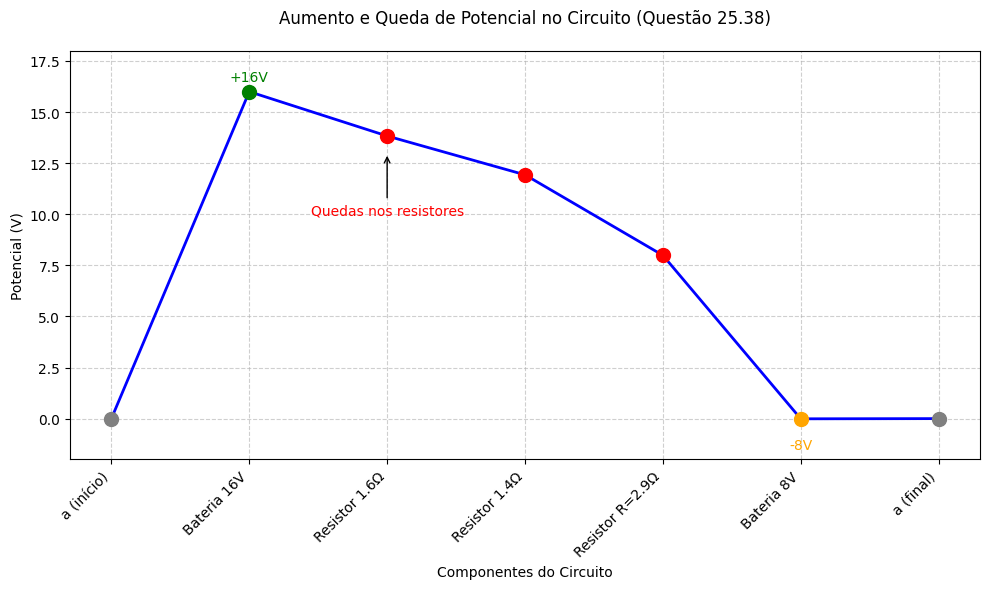

In [ ]:
import matplotlib.pyplot as plt

# Dados do circuito
componentes = ['a (início)', 'Bateria 16V', 'Resistor 1.6Ω', 'Resistor 1.4Ω', 'Resistor R=2.9Ω', 'Bateria 8V', 'a (final)']
potencial = [0, 16, 13.83, 11.93, 7.99, -0.01, 0]  # Valores acumulados em V

# Cores para destaque
cores = ['gray', 'green', 'red', 'red', 'red', 'orange', 'gray']

# Criar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(componentes, potencial, marker='o', linestyle='-', color='blue', linewidth=2)

# Destacar componentes
for i in range(len(componentes)):
    plt.scatter(componentes[i], potencial[i], color=cores[i], s=100, zorder=5)

# Anotações
plt.annotate('+16V', xy=(1, 16), xytext=(1, 16.5), ha='center', fontsize=10, color='green')
plt.annotate('-8V', xy=(5, -0.01), xytext=(5, -1.5), ha='center', fontsize=10, color='orange')
plt.annotate('Quedas nos resistores', xy=(2, 13), xytext=(2, 10),
             arrowprops=dict(arrowstyle='->'), ha='center', fontsize=10, color='red')

# Configurações do gráfico
plt.title('Aumento e Queda de Potencial no Circuito (Questão 25.38)', fontsize=12, pad=20)
plt.xlabel('Componentes do Circuito', fontsize=10)
plt.ylabel('Potencial (V)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-2, 18)

# Mostrar o gráfico
plt.tight_layout()
plt.show()


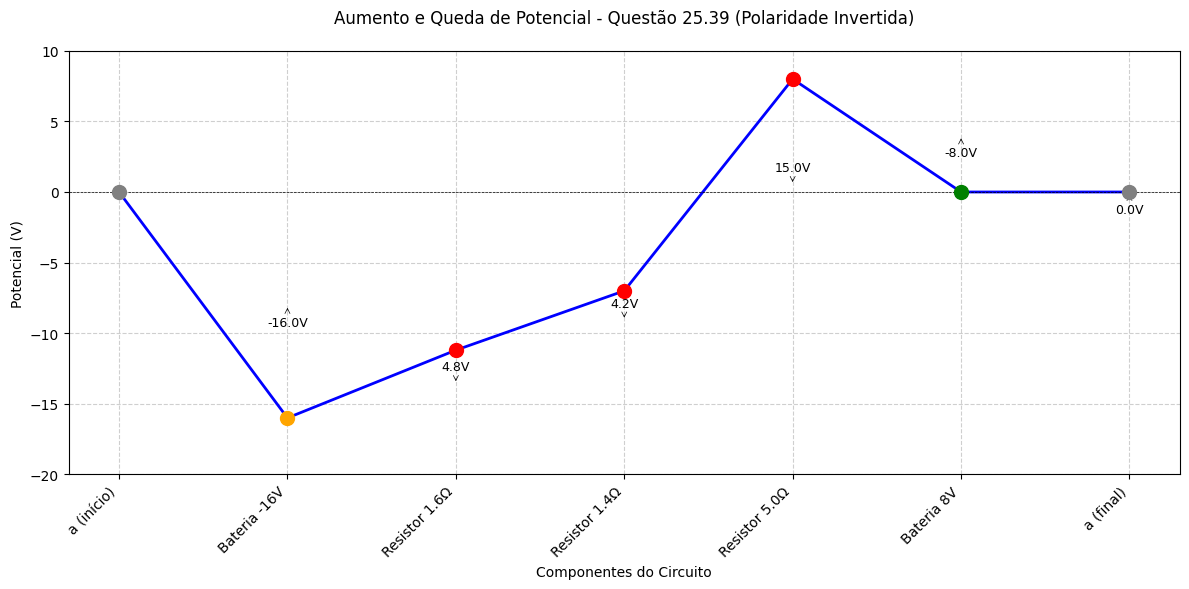

In [ ]:
import matplotlib.pyplot as plt

# Dados do circuito (Questão 25.39)
componentes = ['a (início)', 'Bateria -16V', 'Resistor 1.6Ω', 'Resistor 1.4Ω', 'Resistor 5.0Ω', 'Bateria 8V', 'a (final)']
potencial = [0, -16, -11.2, -7.0, 8.0, 0, 0]  # Valores acumulados em V

# Variações de potencial entre componentes
variacoes = [0, -16, 4.8, 4.2, 15.0, -8.0, 0]  # Quedas e aumentos

# Cores para destaque
cores = ['gray', 'orange', 'red', 'red', 'red', 'green', 'gray']

# Criar o gráfico
plt.figure(figsize=(12, 6))
plt.plot(componentes, potencial, marker='o', linestyle='-', color='blue', linewidth=2, label='Potencial')

# Destacar componentes
for i in range(len(componentes)):
    plt.scatter(componentes[i], potencial[i], color=cores[i], s=100, zorder=5)

# Anotações das variações
for i in range(1, len(componentes)):
    y_pos = (potencial[i-1] + potencial[i]) / 2
    plt.annotate(f'{variacoes[i]:.1f}V',
                 xy=(i, y_pos),
                 xytext=(0, 10 if variacoes[i] > 0 else -15),
                 textcoords='offset points',
                 ha='center',
                 fontsize=9,
                 color='black',
                 arrowprops=dict(arrowstyle='->', lw=0.5))

# Configurações do gráfico
plt.title('Aumento e Queda de Potencial - Questão 25.39 (Polaridade Invertida)', fontsize=12, pad=20)
plt.xlabel('Componentes do Circuito', fontsize=10)
plt.ylabel('Potencial (V)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-20, 10)  # Ajuste para incluir todas as variações

# Linha de referência em 0V
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Mostrar o gráfico
plt.tight_layout()
plt.show()

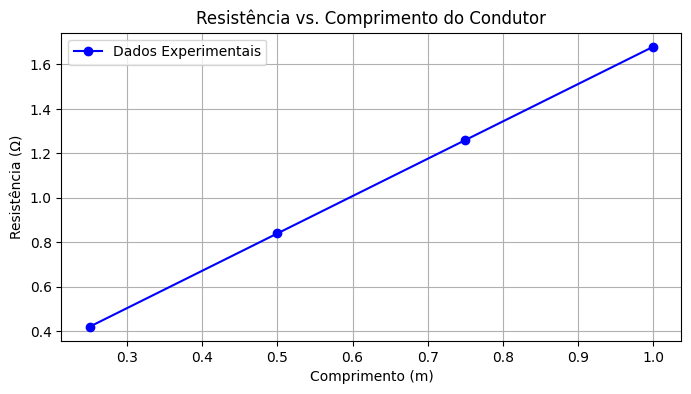

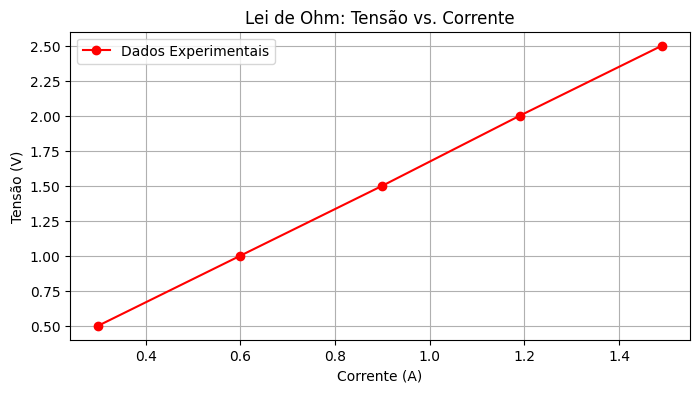

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados simulados - Fase I: Resistência vs. Comprimento (Resistor 1)
L = np.array([0.25, 0.50, 0.75, 1.00])  # Comprimento (m)
R = np.array([0.42, 0.84, 1.26, 1.68])  # Resistência (Ω)

# Gráfico 1: R vs. L
plt.figure(figsize=(8, 4))
plt.plot(L, R, 'bo-', label='Dados Experimentais')
plt.xlabel('Comprimento (m)')
plt.ylabel('Resistência (Ω)')
plt.title('Resistência vs. Comprimento do Condutor')
plt.grid(True)
plt.legend()
plt.show()

# Dados simulados - Fase II: Tensão vs. Corrente (Resistor 4)
V = np.array([0.5, 1.0, 1.5, 2.0, 2.5])  # Tensão (V)
I = np.array([0.30, 0.60, 0.90, 1.19, 1.49])  # Corrente (A)

# Gráfico 2: V vs. I
plt.figure(figsize=(8, 4))
plt.plot(I, V, 'ro-', label='Dados Experimentais')
plt.xlabel('Corrente (A)')
plt.ylabel('Tensão (V)')
plt.title('Lei de Ohm: Tensão vs. Corrente')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Configuração para exibir tabelas bonitas no terminal
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

def resolver_fluxo_cc(barras, linhas, injecoes_mw, barra_slack, base_mva=100):
    """
    Resolve o Fluxo de Potência DC e retorna DataFrames formatados.
    """
    nb = len(barras)
    mapa_idx = {b: i for i, b in enumerate(barras)}

    # 1. Montar Matriz B' (Susceptância)
    B = np.zeros((nb, nb))
    for de, para, x, limite in linhas:
        i, j = mapa_idx[de], mapa_idx[para]
        b_km = 1.0 / x
        B[i, i] += b_km
        B[j, j] += b_km
        B[i, j] -= b_km
        B[j, i] -= b_km

    # 2. Ajustar vetores para cálculo (Remover Slack)
    P_pu = np.array([injecoes_mw[b] / base_mva for b in barras])
    idx_slack = mapa_idx[barra_slack]

    # Remover linha/coluna da slack
    indices_livres = [i for i in range(nb) if i != idx_slack]
    B_red = B[np.ix_(indices_livres, indices_livres)]
    P_red = P_pu[indices_livres]

    # 3. Resolver sistema linear: Theta = inv(B') * P
    theta_red = np.linalg.solve(B_red, P_red)

    # Reconstruir vetor de ângulos completo
    theta_rad = np.zeros(nb)
    for i, val in zip(indices_livres, theta_red):
        theta_rad[i] = val

    theta_graus = np.degrees(theta_rad)

    # 4. Gerar Tabela de Barras (Ângulos)
    df_barras = pd.DataFrame({
        'Barra': barras,
        'Ângulo (Graus)': theta_graus,
        'Injeção Líquida (MW)': [injecoes_mw[b] for b in barras]
    })

    # 5. Calcular Fluxos nas Linhas
    lista_fluxos = []
    for de, para, x, limite in linhas:
        i, j = mapa_idx[de], mapa_idx[para]
        fluxo_pu = (theta_rad[i] - theta_rad[j]) / x
        fluxo_mw = fluxo_pu * base_mva
        perc = (abs(fluxo_mw) / limite * 100) if limite else 0.0

        status = "OK"
        if perc > 100: status = "SOBRECARGA"
        elif perc > 90: status = "ALERTA"

        lista_fluxos.append({
            'Linha': f"{de}-{para}",
            'Fluxo (MW)': fluxo_mw,
            'Capacidade (MW)': limite,
            '% Carregamento': perc,
            'Status': status
        })

    df_linhas = pd.DataFrame(lista_fluxos)

    return df_barras, df_linhas

# ========================================================
# PARTE A: SISTEMA 1 (9 Barras) - Com Slack na Barra 1
# ========================================================
print("\n" + "="*50)
print(" RESULTADOS PARTE A: SISTEMA 1 (Slack = Barra 1)")
print("="*50)

barras_A = [1, 2, 3, 4, 5, 6, 7, 8, 9]
# Linhas: (De, Para, Reatancia X, Limite Estimado)
linhas_A = [
    (1, 2, 0.10, 60), (1, 5, 0.12, 60),
    (2, 3, 0.08, 60), (2, 5, 0.15, 60),
    (3, 4, 0.10, 60),
    (4, 5, 0.12, 60), (4, 7, 0.20, 60), (4, 8, 0.25, 60),
    (5, 6, 0.18, 60),
    (6, 7, 0.12, 60),
    (7, 8, 0.10, 60),
    (8, 9, 0.14, 60)
]
# Injeções (Geração - Carga)
# B1=75, B2=25, B3=50
# B6=-60, B7=-50, B9=-40
P_A = {
    1: 75, 2: 25, 3: 50,
    4: 0, 5: 0,
    6: -60, 7: -50, 8: 0, 9: -40
}

df_angulos_A, df_fluxos_A = resolver_fluxo_cc(barras_A, linhas_A, P_A, barra_slack=1)

print("\n--- Tabela 2: Ângulos das Barras (Corrigido) ---")
print(df_angulos_A[['Barra', 'Ângulo (Graus)']].to_string(index=False))

print("\n--- Tabela 3: Fluxos de Potência (Corrigido) ---")
print(df_fluxos_A.to_string(index=False))


# ========================================================
# PARTE B: SISTEMA B - Despacho Ótimo
# ========================================================
print("\n" + "="*50)
print(" RESULTADOS PARTE B: DESPACHO ÓTIMO (Carga 100 MW)")
print("="*50)

barras_B = [1, 2, 3, 4, 5]
# Assumindo X=0.1 padrão já que não foi dado, mas os limites foram dados
linhas_B = [
    (1, 2, 0.1, 50), (1, 5, 0.1, 20),
    (2, 3, 0.1, 20), (2, 5, 0.1, 60),
    (3, 4, 0.1, 50), (4, 5, 0.1, 20)
]

# --- CENÁRIO 1: ECONÔMICO (Inviável) ---
# G1=70 (max, barato), G2=20 (max), G3=10 (resto)
# Carga: B4=40, B5=60 -> Total 100
P_B_econ = {
    1: 70, 2: 20, 3: 10,
    4: -40, 5: -60
}
custo_econ = (70*2) + (20*3) + (10*5)

print(f"\n>> CENÁRIO 1: Despacho Econômico (Custo Total: R$ {custo_econ:.2f})")
print("Tentativa: G1=70, G2=20, G3=10")
_, df_fluxos_B_econ = resolver_fluxo_cc(barras_B, linhas_B, P_B_econ, barra_slack=1)
print(df_fluxos_B_econ[df_fluxos_B_econ['Status'] != 'OK'].to_string(index=False))
# Nota: Vai mostrar sobrecarga na linha 1-5

# --- CENÁRIO 2: OTIMIZADO (Seguro) ---
# Reduzir G1 para aliviar linha 1-5, aumentar G3
# G1=50, G2=20, G3=30
P_B_otimo = {
    1: 50, 2: 20, 3: 30,
    4: -40, 5: -60
}
custo_otimo = (50*2) + (20*3) + (30*5)

print(f"\n>> CENÁRIO 2: Despacho Seguro/Otimizado (Custo Total: R$ {custo_otimo:.2f})")
print("Solução: G1=50, G2=20, G3=30")
_, df_fluxos_B_otimo = resolver_fluxo_cc(barras_B, linhas_B, P_B_otimo, barra_slack=1)

print("\n--- Tabela Final: Fluxos no Sistema B (Despacho Seguro) ---")
print(df_fluxos_B_otimo.to_string(index=False))

print("\nConclusão Financeira:")
print(f"Aumento de custo pela segurança: R$ {custo_otimo - custo_econ:.2f}")


 RESULTADOS PARTE A: SISTEMA 1 (Slack = Barra 1)

--- Tabela 2: Ângulos das Barras (Corrigido) ---
 Barra  Ângulo (Graus)
     1            0.00
     2           -1.12
     3           -1.73
     4           -5.35
     5           -3.81
     6          -10.45
     7          -10.76
     8          -10.85
     9          -14.06

--- Tabela 3: Fluxos de Potência (Corrigido) ---
Linha  Fluxo (MW)  Capacidade (MW)  % Carregamento     Status
  1-2       19.55               60           32.59         OK
  1-5       55.45               60           92.41     ALERTA
  2-3       13.23               60           22.05         OK
  2-5       31.32               60           52.20         OK
  3-4       63.23               60          105.39 SOBRECARGA
  4-5      -22.36               60           37.27         OK
  4-7       47.20               60           78.66         OK
  4-8       38.40               60           64.00         OK
  5-6       64.41               60          107.35 SOBRECARGA


In [ ]:
import numpy as np
import pandas as pd

# ==============================================================================
# CONFIGURAÇÕES INICIAIS
# ==============================================================================
np.set_printoptions(precision=4, suppress=True, linewidth=200)

def resolver_fluxo_dc(nome_sistema, barras, linhas, injecoes, barra_slack, base_mva=100):
    print(f"\n{'='*60}")
    print(f" RESOLUÇÃO: {nome_sistema}")
    print(f"{'='*60}")

    nb = len(barras)
    mapa = {b: i for i, b in enumerate(barras)}

    # 1. MONTAGEM DA MATRIZ B' (COMPLETA)
    B = np.zeros((nb, nb))
    for de, para, x, lim in linhas:
        i, j = mapa[de], mapa[para]
        b_km = 1.0 / x
        B[i, i] += b_km
        B[j, j] += b_km
        B[i, j] -= b_km
        B[j, i] -= b_km

    print(f"\n--- Matriz B' Completa ({nb}x{nb}) ---")
    print(B)

    # 2. REDUÇÃO (Eliminar linha/coluna da Slack)
    idx_slack = mapa[barra_slack]
    indices_livres = [i for i in range(nb) if i != idx_slack]
    barras_livres = [barras[i] for i in indices_livres]

    B_red = B[np.ix_(indices_livres, indices_livres)]
    P_red = np.array([injecoes[b] for b in barras_livres]) / base_mva

    print(f"\n--- Matriz B' Reduzida (sem barra {barra_slack}) ---")
    print(B_red)

    # 3. RESOLUÇÃO DO SISTEMA LINEAR (P = B * theta)
    try:
        theta_red = np.linalg.solve(B_red, P_red)
    except np.linalg.LinAlgError:
        print("Erro: Matriz singular. Verifique se o sistema está conectado.")
        return

    # Reconstruir vetor completo de ângulos
    theta_rad = np.zeros(nb)
    for i, val in zip(indices_livres, theta_red):
        theta_rad[i] = val

    theta_graus = np.degrees(theta_rad)

    # 4. EXIBIÇÃO DOS RESULTADOS (ÂNGULOS)
    print("\n--- Resultados: Ângulos ---")
    df_ang = pd.DataFrame({
        'Barra': barras,
        'Ângulo (Graus)': theta_graus,
        'Injeção (MW)': [injecoes[b] for b in barras]
    })
    print(df_ang.to_string(index=False))

    # 5. CÁLCULO DE FLUXOS
    print("\n--- Resultados: Fluxos nas Linhas ---")
    fluxos = []
    for de, para, x, lim in linhas:
        i, j = mapa[de], mapa[para]
        fluxo_mw = ((theta_rad[i] - theta_rad[j]) / x) * base_mva
        perc = abs(fluxo_mw) / lim * 100 if lim else 0
        status = "VIOLAÇÃO" if perc > 100 else "OK"

        fluxos.append({
            'Linha': f"{de}-{para}",
            'Fluxo (MW)': fluxo_mw,
            'Limite (MW)': lim if lim else '-',
            '% Carreg.': perc,
            'Status': status
        })

    df_flux = pd.DataFrame(fluxos)
    print(df_flux.to_string(index=False))
    return df_flux

# ==============================================================================
# EXECUÇÃO: PARTE A (SISTEMA 1)
# ==============================================================================
# Dados do PDF (Anexo A.1)
barras_A = [1, 2, 3, 4, 5, 6, 7, 8, 9]
linhas_A = [
    (1, 2, 0.10, 60), (1, 5, 0.12, 60), (2, 3, 0.08, 60), (2, 5, 0.15, 60),
    (3, 4, 0.10, 60), (4, 5, 0.12, 60), (4, 7, 0.20, 60), (4, 8, 0.25, 60),
    (5, 6, 0.18, 60), (6, 7, 0.12, 60), (7, 8, 0.10, 60), (8, 9, 0.14, 60)
] # Nota: Limite de 60MW assumido para análise onde não especificado
injecoes_A = {
    1: 75, 2: 25, 3: 50, 4: 0, 5: 0,
    6: -60, 7: -50, 8: 0, 9: -40
}

# Resolver Parte A (Slack = Barra 1)
resolver_fluxo_dc("PARTE A - SISTEMA 1", barras_A, linhas_A, injecoes_A, barra_slack=1)

# ==============================================================================
# EXECUÇÃO: PARTE B (SISTEMA B) - CENÁRIO OTIMIZADO
# ==============================================================================
# Dados do PDF (Anexo B)
barras_B = [1, 2, 3, 4, 5]
linhas_B = [
    (1, 2, 0.1, 50), (1, 5, 0.1, 20), (2, 3, 0.1, 20),
    (2, 5, 0.1, 60), (3, 4, 0.1, 50), (4, 5, 0.1, 20)
]
# Despacho Proposto (Otimizado/Seguro)
# G1=50, G2=20, G3=30 | Carga B4=40, B5=60
injecoes_B = {
    1: 50,  # G1 Reduzido
    2: 20,  # G2 Max
    3: 30,  # G3 Ajustado
    4: -40, # Carga
    5: -60  # Carga
}

# Resolver Parte B
resolver_fluxo_dc("PARTE B - SISTEMA B (OTIMIZADO)", barras_B, linhas_B, injecoes_B, barra_slack=1)



 RESOLUÇÃO: PARTE A - SISTEMA 1

--- Matriz B' Completa (9x9) ---
[[ 18.3333 -10.       0.       0.      -8.3333   0.       0.       0.       0.    ]
 [-10.      29.1667 -12.5      0.      -6.6667   0.       0.       0.       0.    ]
 [  0.     -12.5     22.5    -10.       0.       0.       0.       0.       0.    ]
 [  0.       0.     -10.      27.3333  -8.3333   0.      -5.      -4.       0.    ]
 [ -8.3333  -6.6667   0.      -8.3333  28.8889  -5.5556   0.       0.       0.    ]
 [  0.       0.       0.       0.      -5.5556  13.8889  -8.3333   0.       0.    ]
 [  0.       0.       0.      -5.       0.      -8.3333  23.3333 -10.       0.    ]
 [  0.       0.       0.      -4.       0.       0.     -10.      21.1429  -7.1429]
 [  0.       0.       0.       0.       0.       0.       0.      -7.1429   7.1429]]

--- Matriz B' Reduzida (sem barra 1) ---
[[ 29.1667 -12.5      0.      -6.6667   0.       0.       0.       0.    ]
 [-12.5     22.5    -10.       0.       0.       0.       0

,Linha,Fluxo (MW),Limite (MW),% Carreg.,Status
0,1-2,10.91,50,21.82,OK
1,1-5,39.09,20,195.45,VIOLAÇÃO
2,2-3,2.73,20,13.64,OK
3,2-5,28.18,60,46.97,OK
4,3-4,32.73,50,65.45,OK
5,4-5,-7.27,20,36.36,OK


In [ ]:
import numpy as np
import pandas as pd

# Configuração para exibir tabelas bonitas no terminal
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

def resolver_fluxo_cc(barras, linhas, injecoes_mw, barra_slack, base_mva=100):
    """
    Resolve o Fluxo de Potência DC e retorna DataFrames formatados.
    """
    nb = len(barras)
    mapa_idx = {b: i for i, b in enumerate(barras)}

    # 1. Montar Matriz B' (Susceptância)
    B = np.zeros((nb, nb))
    for de, para, x, limite in linhas:
        i, j = mapa_idx[de], mapa_idx[para]
        b_km = 1.0 / x
        B[i, i] += b_km
        B[j, j] += b_km
        B[i, j] -= b_km
        B[j, i] -= b_km

    # 2. Ajustar vetores para cálculo (Remover Slack)
    P_pu = np.array([injecoes_mw[b] / base_mva for b in barras])
    idx_slack = mapa_idx[barra_slack]

    # Remover linha/coluna da slack
    indices_livres = [i for i in range(nb) if i != idx_slack]
    B_red = B[np.ix_(indices_livres, indices_livres)]
    P_red = P_pu[indices_livres]

    # 3. Resolver sistema linear: Theta = inv(B') * P
    theta_red = np.linalg.solve(B_red, P_red)

    # Reconstruir vetor de ângulos completo
    theta_rad = np.zeros(nb)
    for i, val in zip(indices_livres, theta_red):
        theta_rad[i] = val

    theta_graus = np.degrees(theta_rad)

    # 4. Gerar Tabela de Barras (Ângulos)
    df_barras = pd.DataFrame({
        'Barra': barras,
        'Ângulo (Graus)': theta_graus,
        'Injeção Líquida (MW)': [injecoes_mw[b] for b in barras]
    })

    # 5. Calcular Fluxos nas Linhas
    lista_fluxos = []
    for de, para, x, limite in linhas:
        i, j = mapa_idx[de], mapa_idx[para]
        fluxo_pu = (theta_rad[i] - theta_rad[j]) / x
        fluxo_mw = fluxo_pu * base_mva
        perc = (abs(fluxo_mw) / limite * 100) if limite else 0.0

        status = "OK"
        if perc > 100: status = "SOBRECARGA"
        elif perc > 90: status = "ALERTA"

        lista_fluxos.append({
            'Linha': f"{de}-{para}",
            'Fluxo (MW)': fluxo_mw,
            'Capacidade (MW)': limite,
            '% Carregamento': perc,
            'Status': status
        })

    df_linhas = pd.DataFrame(lista_fluxos)

    return df_barras, df_linhas

# ========================================================
# PARTE A: SISTEMA 1 (9 Barras) - Com Slack na Barra 1
# ========================================================
print("\n" + "="*50)
print(" RESULTADOS PARTE A: SISTEMA 1 (Slack = Barra 1)")
print("="*50)

barras_A = [1, 2, 3, 4, 5, 6, 7, 8, 9]
# Linhas: (De, Para, Reatancia X, Limite Estimado)
linhas_A = [
    (1, 2, 0.10, 60), (1, 5, 0.12, 60),
    (2, 3, 0.08, 60), (2, 5, 0.15, 60),
    (3, 4, 0.10, 60),
    (4, 5, 0.12, 60), (4, 7, 0.20, 60), (4, 8, 0.25, 60),
    (5, 6, 0.18, 60),
    (6, 7, 0.12, 60),
    (7, 8, 0.10, 60),
    (8, 9, 0.14, 60)
]
# Injeções (Geração - Carga)
# B1=75, B2=25, B3=50
# B6=-60, B7=-50, B9=-40
P_A = {
    1: 75, 2: 25, 3: 50,
    4: 0, 5: 0,
    6: -60, 7: -50, 8: 0, 9: -40
}

df_angulos_A, df_fluxos_A = resolver_fluxo_cc(barras_A, linhas_A, P_A, barra_slack=1)

print("\n--- Tabela 2: Ângulos das Barras (Corrigido) ---")
print(df_angulos_A[['Barra', 'Ângulo (Graus)']].to_string(index=False))

print("\n--- Tabela 3: Fluxos de Potência (Corrigido) ---")
print(df_fluxos_A.to_string(index=False))


# ========================================================
# PARTE B: SISTEMA B - Despacho Ótimo
# ========================================================
print("\n" + "="*50)
print(" RESULTADOS PARTE B: DESPACHO ÓTIMO (Carga 100 MW)")
print("="*50)

barras_B = [1, 2, 3, 4, 5]
# Assumindo X=0.1 padrão já que não foi dado, mas os limites foram dados
linhas_B = [
    (1, 2, 0.1, 50), (1, 5, 0.1, 20),
    (2, 3, 0.1, 20), (2, 5, 0.1, 60),
    (3, 4, 0.1, 50), (4, 5, 0.1, 20)
]

# --- CENÁRIO 1: ECONÔMICO (Inviável) ---
# G1=70 (max, barato), G2=20 (max), G3=10 (resto)
# Carga: B4=40, B5=60 -> Total 100
P_B_econ = {
    1: 70, 2: 20, 3: 10,
    4: -40, 5: -60
}
custo_econ = (70*2) + (20*3) + (10*5)

print(f"\n>> CENÁRIO 1: Despacho Econômico (Custo Total: R$ {custo_econ:.2f})")
print("Tentativa: G1=70, G2=20, G3=10")
_, df_fluxos_B_econ = resolver_fluxo_cc(barras_B, linhas_B, P_B_econ, barra_slack=1)
print(df_fluxos_B_econ[df_fluxos_B_econ['Status'] != 'OK'].to_string(index=False))
# Nota: Vai mostrar sobrecarga na linha 1-5

# --- CENÁRIO 2: OTIMIZADO (Seguro) ---
# Reduzir G1 para aliviar linha 1-5, aumentar G3
# G1=50, G2=20, G3=30
P_B_otimo = {
    1: 50, 2: 20, 3: 30,
    4: -40, 5: -60
}
custo_otimo = (50*2) + (20*3) + (30*5)

print(f"\n>> CENÁRIO 2: Despacho Seguro/Otimizado (Custo Total: R$ {custo_otimo:.2f})")
print("Solução: G1=50, G2=20, G3=30")
_, df_fluxos_B_otimo = resolver_fluxo_cc(barras_B, linhas_B, P_B_otimo, barra_slack=1)

print("\n--- Tabela Final: Fluxos no Sistema B (Despacho Seguro) ---")
print(df_fluxos_B_otimo.to_string(index=False))

print("\nConclusão Financeira:")
print(f"Aumento de custo pela segurança: R$ {custo_otimo - custo_econ:.2f}")


 RESULTADOS PARTE A: SISTEMA 1 (Slack = Barra 1)

--- Tabela 2: Ângulos das Barras (Corrigido) ---
 Barra  Ângulo (Graus)
     1            0.00
     2           -1.12
     3           -1.73
     4           -5.35
     5           -3.81
     6          -10.45
     7          -10.76
     8          -10.85
     9          -14.06

--- Tabela 3: Fluxos de Potência (Corrigido) ---
Linha  Fluxo (MW)  Capacidade (MW)  % Carregamento     Status
  1-2       19.55               60           32.59         OK
  1-5       55.45               60           92.41     ALERTA
  2-3       13.23               60           22.05         OK
  2-5       31.32               60           52.20         OK
  3-4       63.23               60          105.39 SOBRECARGA
  4-5      -22.36               60           37.27         OK
  4-7       47.20               60           78.66         OK
  4-8       38.40               60           64.00         OK
  5-6       64.41               60          107.35 SOBRECARGA


In [ ]:
import numpy as np
import pandas as pd

# ==============================================================================
# CONFIGURAÇÕES INICIAIS
# ==============================================================================
np.set_printoptions(precision=4, suppress=True, linewidth=200)

def resolver_fluxo_dc(nome_sistema, barras, linhas, injecoes, barra_slack, base_mva=100):
    print(f"\n{'='*60}")
    print(f" RESOLUÇÃO: {nome_sistema}")
    print(f"{'='*60}")

    nb = len(barras)
    mapa = {b: i for i, b in enumerate(barras)}

    # 1. MONTAGEM DA MATRIZ B' (COMPLETA)
    B = np.zeros((nb, nb))
    for de, para, x, lim in linhas:
        i, j = mapa[de], mapa[para]
        b_km = 1.0 / x
        B[i, i] += b_km
        B[j, j] += b_km
        B[i, j] -= b_km
        B[j, i] -= b_km

    print(f"\n--- Matriz B' Completa ({nb}x{nb}) ---")
    print(B)

    # 2. REDUÇÃO (Eliminar linha/coluna da Slack)
    idx_slack = mapa[barra_slack]
    indices_livres = [i for i in range(nb) if i != idx_slack]
    barras_livres = [barras[i] for i in indices_livres]

    B_red = B[np.ix_(indices_livres, indices_livres)]
    P_red = np.array([injecoes[b] for b in barras_livres]) / base_mva

    print(f"\n--- Matriz B' Reduzida (sem barra {barra_slack}) ---")
    print(B_red)

    # 3. RESOLUÇÃO DO SISTEMA LINEAR (P = B * theta)
    try:
        theta_red = np.linalg.solve(B_red, P_red)
    except np.linalg.LinAlgError:
        print("Erro: Matriz singular. Verifique se o sistema está conectado.")
        return

    # Reconstruir vetor completo de ângulos
    theta_rad = np.zeros(nb)
    for i, val in zip(indices_livres, theta_red):
        theta_rad[i] = val

    theta_graus = np.degrees(theta_rad)

    # 4. EXIBIÇÃO DOS RESULTADOS (ÂNGULOS)
    print("\n--- Resultados: Ângulos ---")
    df_ang = pd.DataFrame({
        'Barra': barras,
        'Ângulo (Graus)': theta_graus,
        'Injeção (MW)': [injecoes[b] for b in barras]
    })
    print(df_ang.to_string(index=False))

    # 5. CÁLCULO DE FLUXOS
    print("\n--- Resultados: Fluxos nas Linhas ---")
    fluxos = []
    for de, para, x, lim in linhas:
        i, j = mapa[de], mapa[para]
        fluxo_mw = ((theta_rad[i] - theta_rad[j]) / x) * base_mva
        perc = abs(fluxo_mw) / lim * 100 if lim else 0
        status = "VIOLAÇÃO" if perc > 100 else "OK"

        fluxos.append({
            'Linha': f"{de}-{para}",
            'Fluxo (MW)': fluxo_mw,
            'Limite (MW)': lim if lim else '-',
            '% Carreg.': perc,
            'Status': status
        })

    df_flux = pd.DataFrame(fluxos)
    print(df_flux.to_string(index=False))
    return df_flux

# ==============================================================================
# EXECUÇÃO: PARTE A (SISTEMA 1)
# ==============================================================================
# Dados do PDF (Anexo A.1)
barras_A = [1, 2, 3, 4, 5, 6, 7, 8, 9]
linhas_A = [
    (1, 2, 0.10, 60), (1, 5, 0.12, 60), (2, 3, 0.08, 60), (2, 5, 0.15, 60),
    (3, 4, 0.10, 60), (4, 5, 0.12, 60), (4, 7, 0.20, 60), (4, 8, 0.25, 60),
    (5, 6, 0.18, 60), (6, 7, 0.12, 60), (7, 8, 0.10, 60), (8, 9, 0.14, 60)
] # Nota: Limite de 60MW assumido para análise onde não especificado
injecoes_A = {
    1: 75, 2: 25, 3: 50, 4: 0, 5: 0,
    6: -60, 7: -50, 8: 0, 9: -40
}

# Resolver Parte A (Slack = Barra 1)
resolver_fluxo_dc("PARTE A - SISTEMA 1", barras_A, linhas_A, injecoes_A, barra_slack=1)

# ==============================================================================
# EXECUÇÃO: PARTE B (SISTEMA B) - CENÁRIO OTIMIZADO
# ==============================================================================
# Dados do PDF (Anexo B)
barras_B = [1, 2, 3, 4, 5]
linhas_B = [
    (1, 2, 0.1, 50), (1, 5, 0.1, 20), (2, 3, 0.1, 20),
    (2, 5, 0.1, 60), (3, 4, 0.1, 50), (4, 5, 0.1, 20)
]
# Despacho Proposto (Otimizado/Seguro)
# G1=50, G2=20, G3=30 | Carga B4=40, B5=60
injecoes_B = {
    1: 50,  # G1 Reduzido
    2: 20,  # G2 Max
    3: 30,  # G3 Ajustado
    4: -40, # Carga
    5: -60  # Carga
}

# Resolver Parte B
resolver_fluxo_dc("PARTE B - SISTEMA B (OTIMIZADO)", barras_B, linhas_B, injecoes_B, barra_slack=1)



 RESOLUÇÃO: PARTE A - SISTEMA 1

--- Matriz B' Completa (9x9) ---
[[ 18.3333 -10.       0.       0.      -8.3333   0.       0.       0.       0.    ]
 [-10.      29.1667 -12.5      0.      -6.6667   0.       0.       0.       0.    ]
 [  0.     -12.5     22.5    -10.       0.       0.       0.       0.       0.    ]
 [  0.       0.     -10.      27.3333  -8.3333   0.      -5.      -4.       0.    ]
 [ -8.3333  -6.6667   0.      -8.3333  28.8889  -5.5556   0.       0.       0.    ]
 [  0.       0.       0.       0.      -5.5556  13.8889  -8.3333   0.       0.    ]
 [  0.       0.       0.      -5.       0.      -8.3333  23.3333 -10.       0.    ]
 [  0.       0.       0.      -4.       0.       0.     -10.      21.1429  -7.1429]
 [  0.       0.       0.       0.       0.       0.       0.      -7.1429   7.1429]]

--- Matriz B' Reduzida (sem barra 1) ---
[[ 29.1667 -12.5      0.      -6.6667   0.       0.       0.       0.    ]
 [-12.5     22.5    -10.       0.       0.       0.       0

,Linha,Fluxo (MW),Limite (MW),% Carreg.,Status
0,1-2,10.91,50,21.82,OK
1,1-5,39.09,20,195.45,VIOLAÇÃO
2,2-3,2.73,20,13.64,OK
3,2-5,28.18,60,46.97,OK
4,3-4,32.73,50,65.45,OK
5,4-5,-7.27,20,36.36,OK
